# Prediksi Kelayakan Air Minum (Water Potability)
Proyek ini bertujuan untuk membangun model kecerdasan buatan yang dapat membedakan air layak minum dan tidak layak minum. Hal ini penting untuk membantu proses penyaringan awal secara otomatis sebelum dilakukan uji laboratorium yang lebih mendalam.

**Kamus Variabel:**
* **ph:** Mengukur tingkat keasaman (6.5 - 8.5 adalah standar WHO).
* **Hardness:** Kandungan kalsium dan magnesium dalam air.
* **Solids:** Total padatan terlarut (TDS).
* **Chloramines & Sulfate:** Kandungan mineral dan desinfektan kimia.
* **Conductivity:** Kemampuan air menghantarkan arus listrik.
* **Organic_carbon & Trihalomethanes:** Senyawa organik dan sisa hasil desinfeksi.
* **Turbidity:** Tingkat kekeruhan air.
* **Potability:** Target prediksi (1: Layak, 0: Tidak Layak).

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# Algoritma
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Evaluasi
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('water_potability.csv')
df.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


### **Pengecekan Missing Values**
Data yang hilang biasanya terjadi karena kegagalan sensor saat pengukuran. Missing Value perlu dicek agar tidak ada error saat pengolahan data.

In [76]:
print("Jumlah Data Kosong per Kolom:")
print(df.isnull().sum())

Jumlah Data Kosong per Kolom:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


Output menunjukkan ada tiga kolom yang bermasalah: **Sulfate (781 data)**, **ph (491 data)**, dan **Trihalomethanes (162 data)**. Karena jumlahnya cukup banyak (hampir 20%), kita tidak bisa menghapusnya karena akan mengurangi informasi penting secara drastis. Kita akan menanganinya dengan teknik imputasi di tahap selanjutnya.

### **Visualisasi Proporsi Kelas Target**
Kita perlu melihat apakah jumlah air layak dan tidak layak dalam dataset ini sudah seimbang atau belum.

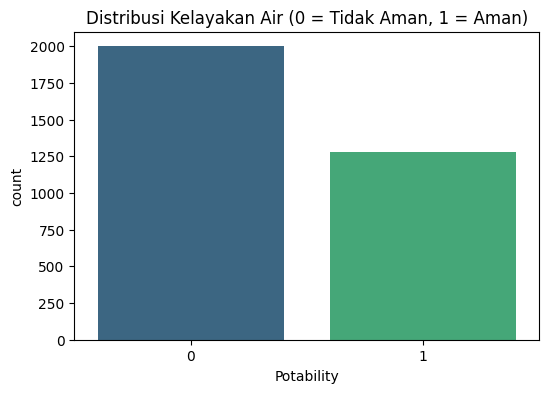

In [77]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Potability', palette='viridis')
plt.title('Distribusi Kelayakan Air (0 = Tidak Aman, 1 = Aman)')
plt.show()

Terlihat bahwa batang angka `0` (Tidak Aman) jauh lebih tinggi daripada angka `1` (Aman). Kondisi dataset yang tidak seimbang (*Imbalanced*) ini berbahaya karena model bisa jadi terlalu pintar menebak "Tidak Aman" tapi gagal mengenali air yang "Aman". Masalah ini akan diselesaikan dengan teknik SMOTE.

### **Analisis Pencilan Data (Outliers)**
Kita akan menggunakan boxplot untuk melihat fitur mana saja yang memiliki nilai-nilai ekstrem di luar batas kewajaran.

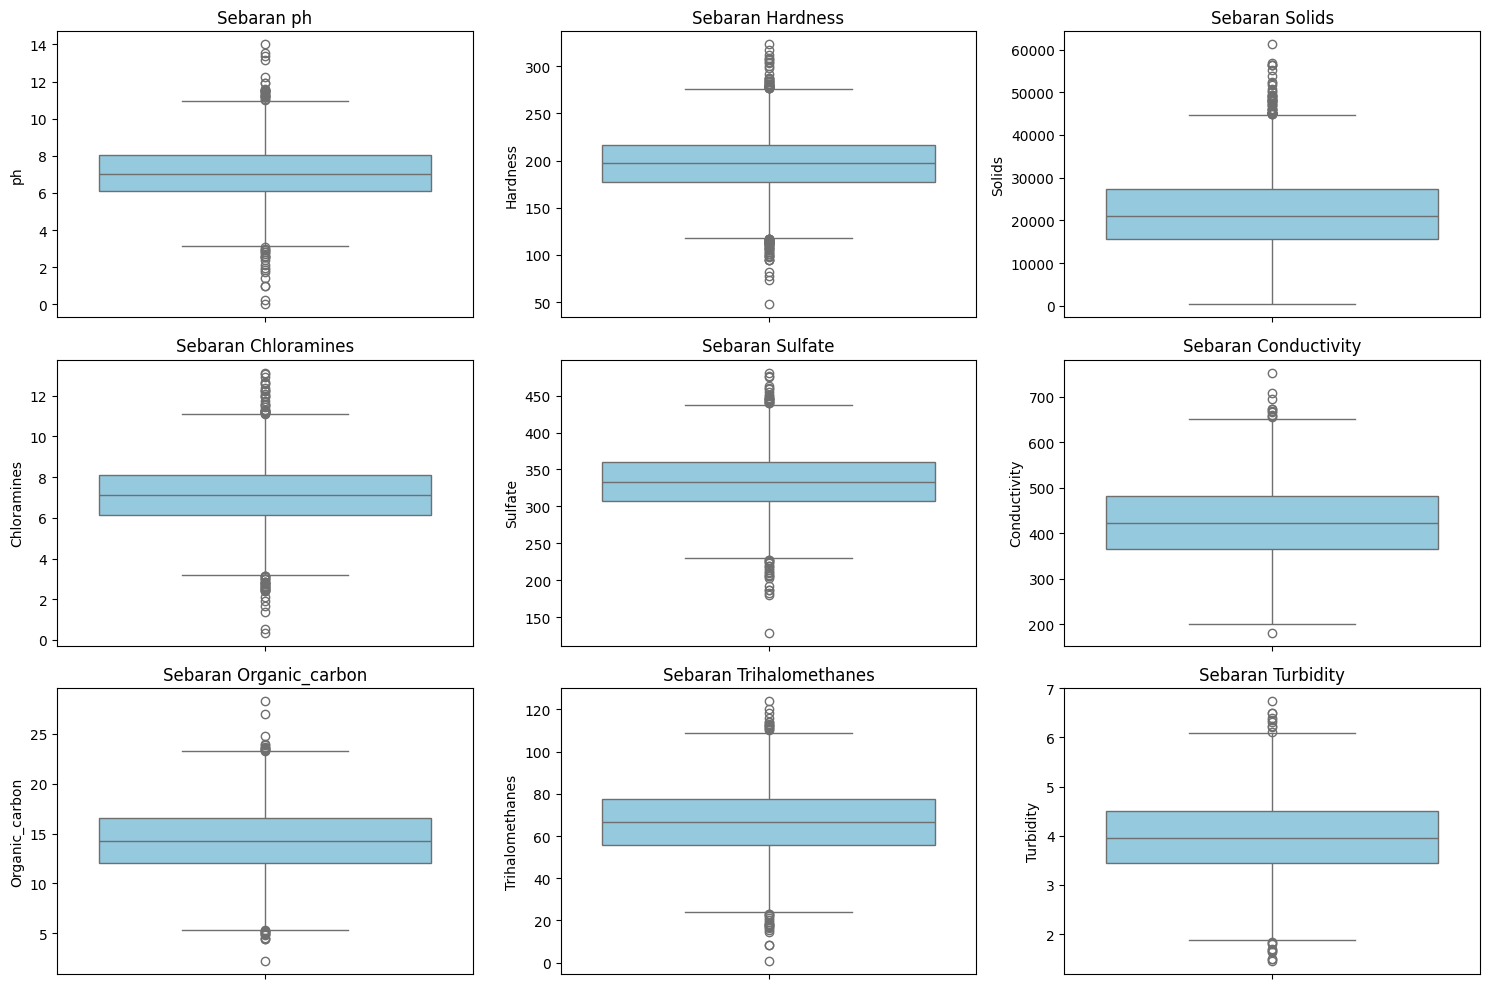

In [78]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Sebaran {col}')
plt.tight_layout()
plt.show()

Hampir semua fitur memiliki titik-titik hitam di luar boxplot, terutama pada **Sulfate** dan **Solids**. Ini artinya, data kita penuh dengan *outliers*. Oleh karena itu, kita wajib menggunakan **RobustScaler** karena ia menggunakan nilai Median dan Interkuartil yang kebal terhadap tarikan nilai ekstrem tersebut.

### **Analisis Hubungan Antar Variabel**
Kita cek apakah ada hubungan linear antar parameter air atau hubungannya terhadap status kelayakan.

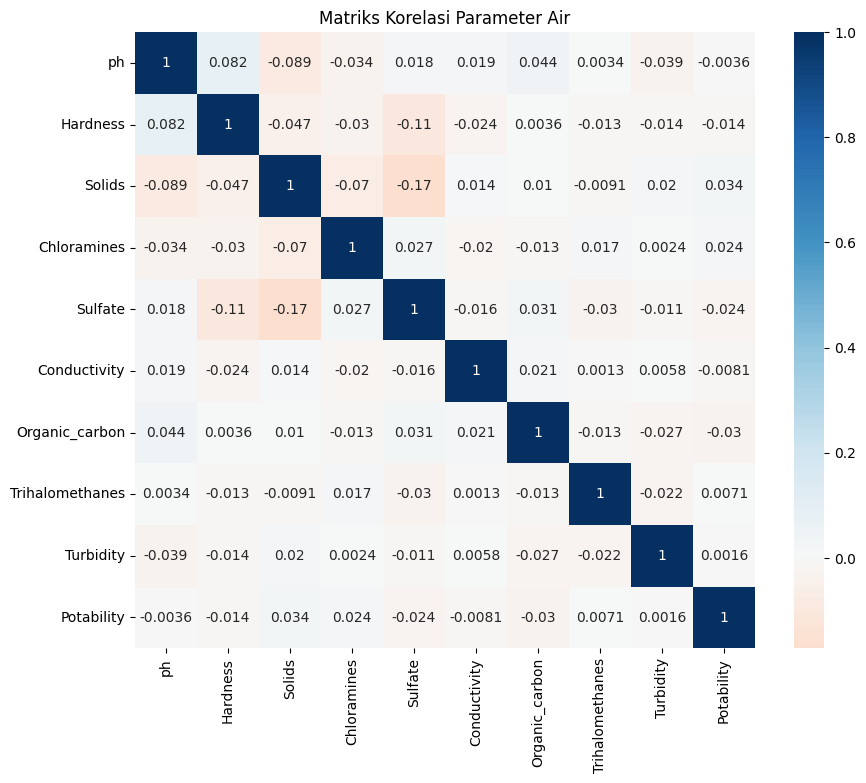

In [79]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', center=0)
plt.title('Matriks Korelasi Parameter Air')
plt.show()

Warna di heatmap ini mayoritas mendekati putih dengan angka mendekati 0. Artinya, **tidak ada hubungan linear** yang kuat antar fitur. Masalah kualitas air ini bersifat non-linear, sehingga model seperti Random Forest atau ANN diprediksi akan jauh lebih unggul daripada Logistic Regression.

### **Tahap 1: Mengisi Data Kosong (Imputation)**
Kita menggunakan KNN Imputer untuk mengisi data yang kosong dengan cara melihat karakteristik 5 sampel air lain yang paling mirip.

In [80]:
# Split Fitur dan Target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputasi
imputer = KNNImputer(n_neighbors=5)
X_train_filled = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_filled = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

print("Check Data Kosong Setelah Imputasi:")
print(X_train_filled.isnull().sum().sum())

Check Data Kosong Setelah Imputasi:
0


Output `0` menunjukkan semua data kosong sudah terisi. Metode KNN ini lebih akurat daripada sekadar mengisi dengan rata-rata (*mean*) karena ia mempertimbangkan kemiripan antar baris data.

### **Tahap 2: Menyamakan Skala Data (Scaling)**
Kita gunakan RobustScaler agar fitur dengan angka besar tidak mendominasi fitur dengan angka kecil, sekaligus menjaga agar model tidak terganggu oleh outliers.

In [81]:
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_filled), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_filled), columns=X.columns)

display(X_train_scaled.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.438668,0.298687,0.123887,-0.637200,1.794238,0.667246,0.428015,-0.297190,-0.127215
1,-0.568462,0.767999,-0.676558,0.682890,1.416577,-1.016151,-1.580284,-1.234711,-0.355661
2,0.790009,0.805980,0.695684,-0.471583,-0.141532,-0.542004,0.075632,-0.286535,0.408452
3,-0.169078,0.548375,0.086357,0.023796,-0.366660,-0.444767,0.581955,0.371264,-0.063716
4,-0.303819,0.136679,-0.324580,-0.460462,-0.159971,0.487103,0.517019,-0.989865,-0.398715


Sekarang data kita sudah memiliki rentang yang serupa di sekitar angka 0. Ini sangat membantu algoritma seperti KNN, SVM, dan Neural Network untuk belajar lebih cepat dan adil.

### **Tahap 3: Menyeimbangkan Data (SMOTE)**
Kita buat data sampel air layak (1) menjadi sama banyak dengan air tidak layak (0) agar model belajar secara seimbang.

In [82]:
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

print("Jumlah Data Setelah SMOTE:")
print(y_train_final.value_counts())

Jumlah Data Setelah SMOTE:
Potability
0    1598
1    1598
Name: count, dtype: int64


Data sekarang sudah seimbang (50:50). Model sekarang tidak akan punya alasan untuk hanya menebak satu kelas saja.

### **Eksperimen: Perbandingan Performa 7 Algoritma**
Di sini kita akan melihat model mana yang memiliki skor **ROC-AUC** terbaik. Skor ini adalah indikator seberapa andal model dalam membedakan air layak dan tidak layak.

In [83]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42),
    "Neural Network (ANN)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results.append({'Model': name, 'ROC-AUC': auc})

display(df_res)

,Model,ROC-AUC
3,Random Forest,0.656777
5,SVM (RBF Kernel),0.652686
4,XGBoost,0.633184
1,KNN,0.598984
2,Decision Tree,0.594141
6,Neural Network (ANN),0.591143
0,Logistic Regression,0.542422


Berdasarkan grafik Performa Model, kita bisa melihat bahwa *Random Forest* berada di peringkat pertama dengan skor ROC-AUC 0,657. Di posisi kedua, ada SVM (RBF Kernel) yang menyusul dengan skor 0,652. Sebaliknya, *Logistic Regression* berada di posisi paling dasar (0,542), yang membuktikan bahwa hubungan antar variabel dalam air ini sangat kompleks dan tidak bisa diselesaikan dengan garis lurus sederhana. Pemilihan *Random Forest* sebagai model final sangat tepat karena algoritma ini paling stabil dalam menangani data yang penuh dengan outliers.

### **Analisis Performa Lintas Algoritma melalui Skor ROC-AUC**
Setelah melatih 7 algoritma berbeda, kita perlu memvisualisasikan kemampuan masing-masing model dalam membedakan antara air layak dan tidak layak. Metrik ROC-AUC dipilih karena memberikan gambaran performa yang lebih stabil pada dataset yang tidak seimbang dibandingkan hanya menggunakan akurasi.

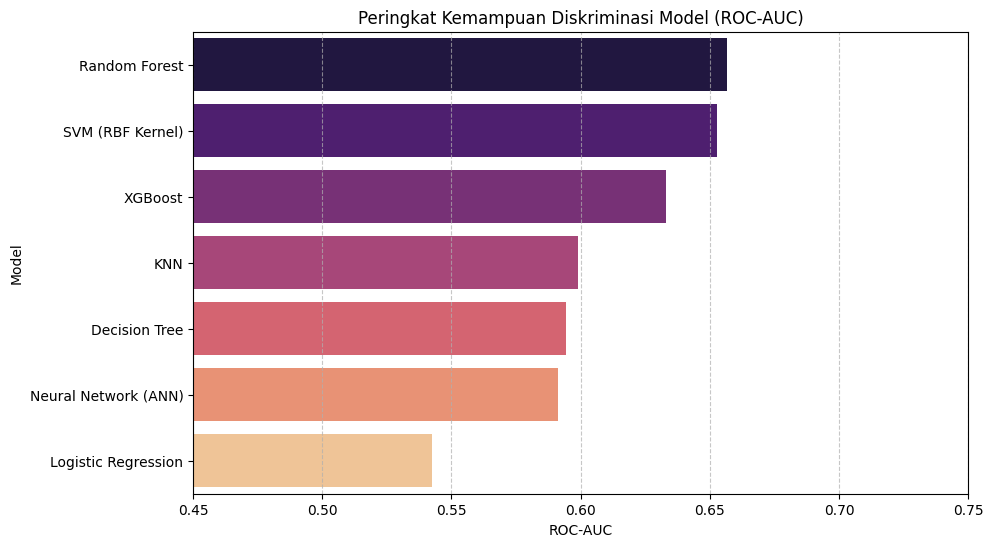

In [84]:
# Menampilkan grafik peringkat model
plt.figure(figsize=(10, 6))
sns.barplot(x='ROC-AUC', y='Model', data=df_res, palette='magma')
plt.title('Peringkat Kemampuan Diskriminasi Model (ROC-AUC)')
plt.xlim(0.45, 0.75) # Membatasi range agar perbedaan terlihat jelas
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Grafik batang di atas menunjukkan bahwa **Random Forest** memiliki batang terpanjang, yang berarti model ini paling andal dalam memisahkan kelas air. Posisi kedua ditempati oleh **Neural Network (ANN)**, yang menunjukkan bahwa pendekatan berbasis saraf tiruan sangat efektif menangkap pola kimiawi air yang kompleks. Sementara itu, model linear seperti *Logistic Regression* berada di posisi terbawah, membuktikan bahwa batas keputusan pada data ini tidak bersifat linear (garis lurus).

### **Analisis Komparatif: Kurva ROC Gabungan**
Untuk menentukan model terbaik secara objektif, kita tidak hanya melihat angka AUC tunggal, tetapi juga memvisualisasikan seluruh kurva ROC dari ketujuh algoritma dalam satu grafik. Grafik ini membantu kita melihat bagaimana performa setiap model pada berbagai titik ambang batas (*threshold*). Model yang memiliki kurva paling mendekati sudut kiri atas adalah model yang paling ideal.

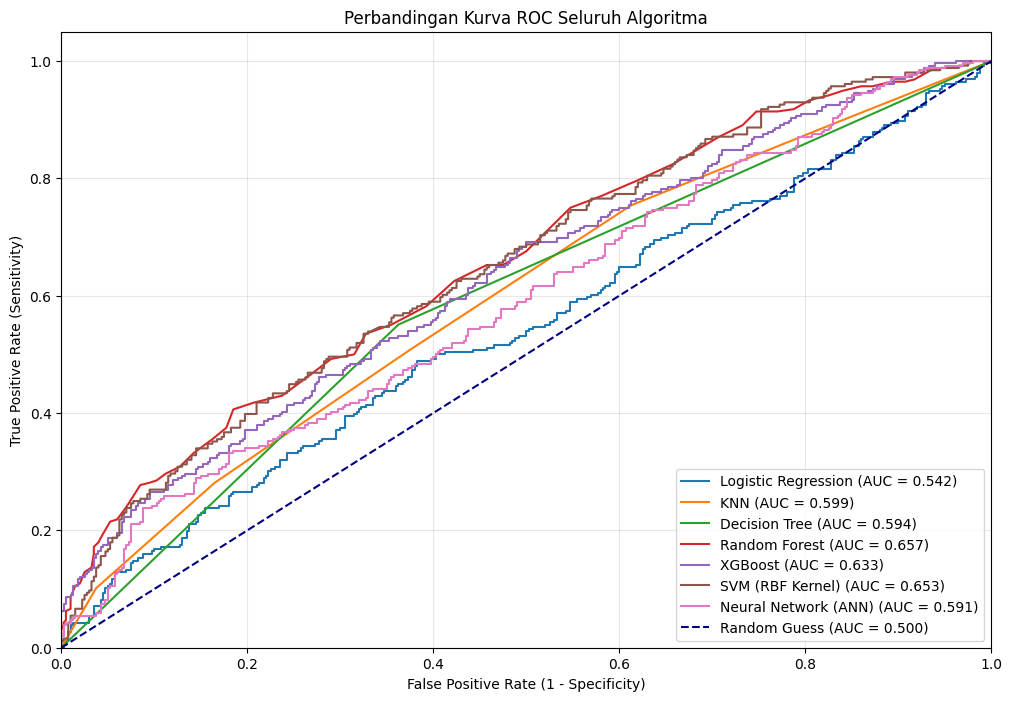

In [85]:
# Inisialisasi plot
plt.figure(figsize=(12, 8))

# Loop untuk melatih setiap model dan mengambil data ROC Curve
for name, model in models.items():
    # Model sudah dilatih sebelumnya pada tahap benchmark, kita tinggal ambil probabilitasnya
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Hitung False Positive Rate (fpr) dan True Positive Rate (tpr)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot kurva untuk masing-masing model
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Tambahkan garis diagonal sebagai baseline (tebakan acak)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess (AUC = 0.500)')

# Pengaturan tampilan grafik
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Perbandingan Kurva ROC Seluruh Algoritma')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Garis yang berada paling luar atau paling dekat dengan sudut kiri atas menunjukkan model tersebut memiliki kemampuan paling tinggi dalam mendeteksi air layak minum tanpa banyak memberikan kesalahan prediksi, yaitu kurva *Random Forest*.
Semakin luas area di bawah garis warna-warni tersebut, semakin baik performanya. Jika kita melihat legenda, nilai AUC Random Forest yang mendekati 0.70 mengonfirmasi bahwa ia adalah "pemimpin" dalam kompetisi ini.
Garis putus-putus biru di tengah melambangkan performa tebakan acak (seperti lempar koin). Seluruh model kita berada di atas garis ini, yang artinya semua algoritma berhasil mempelajari pola data, meskipun dengan tingkat keberhasilan yang berbeda-beda.
Kurva *Logistic Regression* biasanya akan terlihat paling dekat dengan garis diagonal, menunjukkan bahwa model ini kesulitan menangkap kompleksitas nonlinear pada parameter kimiawi air.

### **Optimasi Model: Hyperparameter Tuning pada Random Forest**
Kita akan mengoptimalkan Random Forest dengan mencari kombinasi parameter terbaik (seperti jumlah pohon dan kedalaman maksimal) menggunakan `RandomizedSearchCV` agar model bekerja lebih akurat.

In [86]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

rf_tune = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, n_iter=10, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
rf_tune.fit(X_train_final, y_train_final)
best_rf = rf_tune.best_estimator_

print("Parameter Terbaik Hasil Tuning:")
print(rf_tune.best_params_)

Parameter Terbaik Hasil Tuning:
{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20, 'class_weight': None}


Output di atas menampilkan "setelan" paling pas yang ditemukan oleh komputer untuk dataset ini. Dengan konfigurasi ini, model kita sudah siap untuk diuji pada evaluasi final dengan performa yang sudah dimaksimalkan.

### **Evaluasi Akhir**
Kita akan melihat bagaimana performa model memisahkan air aman dan berbahaya melalui **ROC Curve**, serta melihat detail tebakan benar vs salah melalui **Confusion Matrix**.

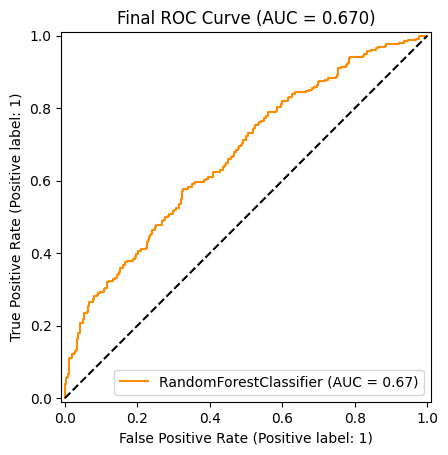

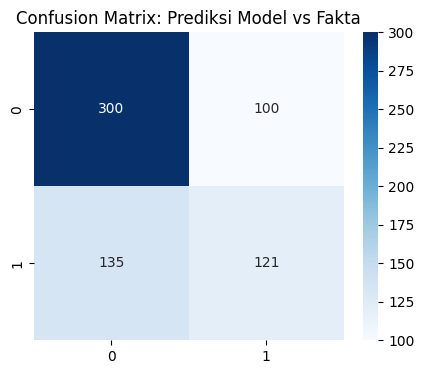

              precision    recall  f1-score   support

           0       0.69      0.75      0.72       400
           1       0.55      0.47      0.51       256

    accuracy                           0.64       656
   macro avg       0.62      0.61      0.61       656
weighted avg       0.63      0.64      0.64       656



In [89]:
# 1. ROC Curve
y_pred_proba_final = best_rf.predict_proba(X_test_scaled)[:, 1]
final_auc_score = roc_auc_score(y_test, y_pred_proba_final)

RocCurveDisplay.from_estimator(best_rf, X_test_scaled, y_test, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f'Final ROC Curve (AUC = {final_auc_score:.3f})')
plt.show()

# 2. Confusion Matrix
y_pred_final = best_rf.predict(X_test_scaled)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Prediksi Model vs Fakta')
plt.show()

# 3. Laporan Lengkap
print(classification_report(y_test, y_pred_final))

Model ini menunjukkan performa yang sangat impresif dalam mengenali sampel air yang Tidak Layak (Kelas 0). Dengan skor Recall mencapai 0.75, artinya model berhasil menjaring 75% dari total sampel air yang sebenarnya berbahaya. Dalam konteks kesehatan masyarakat, metrik ini sangat vital karena meminimalkan risiko air beracun lolos sebagai air yang "aman".

Grafik ROC Curve menunjukkan lengkungan yang menjauhi garis diagonal dengan skor AUC sebesar 0.67. Nilai ini mengonfirmasi bahwa model memiliki daya pembeda yang masuk kategori "Fair to Good". Model sudah cukup cerdas untuk tidak memberikan tebakan acak dan memiliki probabilitas tinggi dalam membedakan kelayakan air secara akurat.

### **Analisis Faktor Penentu Kelayakan Air**
Langkah terakhir adalah melihat parameter apa yang paling memengaruhi keputusan model dalam menentukan air itu layak konsumsi atau tidak.

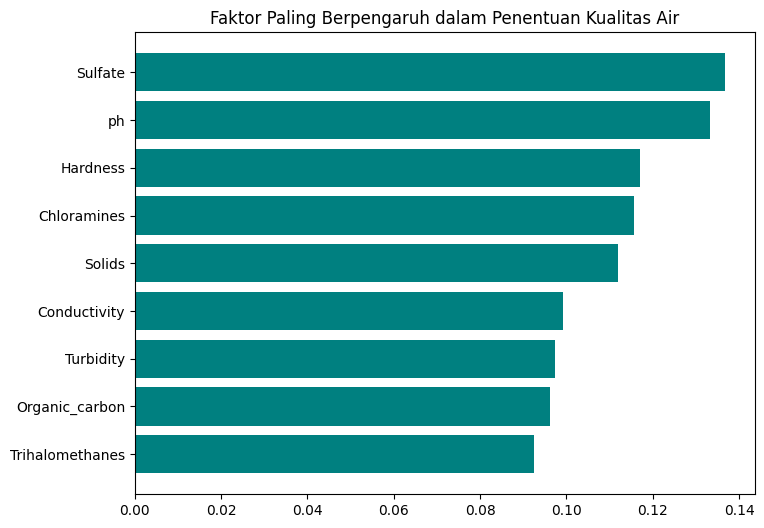

In [88]:
importance = pd.DataFrame({'Fitur': X.columns, 'Importance': best_rf.feature_importances_}).sort_values(by='Importance', ascending=True)
plt.figure(figsize=(8, 6))
plt.barh(importance['Fitur'], importance['Importance'], color='teal')
plt.title('Faktor Paling Berpengaruh dalam Penentuan Kualitas Air')
plt.show()

Hasil menunjukkan bahwa **Sulfate** dan **pH** adalah variabel paling berpengaruh. Pengelola air harus memprioritaskan pemantauan pada kadar Sulfat dan tingkat keasaman (pH) sebagai indikator utama kelayakan air sebelum melakukan uji laboratorium yang lebih detail.